In [73]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(cowplot)
library(vegan)
library(RColorBrewer)
library("viridis")  

# Jaccard===============================================================================

## File ordering----------------------------------------------------------------------------------------------------------------------------------------------------------------

In [74]:
# Read file tp1 
jaccard_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/2025-09-24_jaccard_merged_tp1.csv" , header = TRUE, check.names = FALSE, quote='"') 
dim(jaccard_tp1)
head(jaccard_tp1)

[1] 50 64

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,100000128343,0.12729614,-0.03936110,0.01090492,-0.056825655,-0.08355026,-0.01735660,0.0462485358,0.038815715,0.10229624,⋯,4,Yes,60,21,1,0,0,0,0,NA
2,100000158999,-0.09985821,-0.12854117,0.03738915,-0.058777547,0.11718727,-0.13892703,0.0221243592,-0.008998215,-0.03456363,⋯,3,No,55,21,1,0,0,0,0,18.5-25 Normal weight
3,100000101469,0.17495223,0.06652195,-0.08715626,-0.120450732,-0.06101174,-0.10963894,-0.0579052670,0.002346942,0.01207300,⋯,2,No,67,25,1,0,0,0,0,NA
4,100000103241,0.18712309,-0.11899808,-0.18483461,0.016208737,-0.07551020,0.03962517,-0.0009814007,-0.012595081,0.06338686,⋯,3,Yes,67,25,1,0,0,0,0,> 25 Overweight
5,100000141564,-0.07361033,-0.13640994,0.08059180,-0.049531426,0.07069381,0.06348747,-0.2141702039,-0.196665174,-0.11165089,⋯,3,No,97,36,1,0,0,1,1,> 25 Overweight
6,100000157404,-0.03917225,0.09299949,0.09004565,-0.003623306,-0.24477286,-0.03103273,-0.1164721967,0.024363263,-0.06630629,⋯,3,No,56,21,1,0,0,0,1,18.5-25 Normal weight


In [75]:
# Add column with timepoint 1
jaccard_tp1 <- jaccard_tp1 |> 
    mutate(tp = as.factor("tp1"))
head(jaccard_tp1)

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<fct>
1,100000128343,0.12729614,-0.03936110,0.01090492,-0.056825655,-0.08355026,-0.01735660,0.0462485358,0.038815715,0.10229624,⋯,Yes,60,21,1,0,0,0,0,NA,tp1
2,100000158999,-0.09985821,-0.12854117,0.03738915,-0.058777547,0.11718727,-0.13892703,0.0221243592,-0.008998215,-0.03456363,⋯,No,55,21,1,0,0,0,0,18.5-25 Normal weight,tp1
3,100000101469,0.17495223,0.06652195,-0.08715626,-0.120450732,-0.06101174,-0.10963894,-0.0579052670,0.002346942,0.01207300,⋯,No,67,25,1,0,0,0,0,NA,tp1
4,100000103241,0.18712309,-0.11899808,-0.18483461,0.016208737,-0.07551020,0.03962517,-0.0009814007,-0.012595081,0.06338686,⋯,Yes,67,25,1,0,0,0,0,> 25 Overweight,tp1
5,100000141564,-0.07361033,-0.13640994,0.08059180,-0.049531426,0.07069381,0.06348747,-0.2141702039,-0.196665174,-0.11165089,⋯,No,97,36,1,0,0,1,1,> 25 Overweight,tp1
6,100000157404,-0.03917225,0.09299949,0.09004565,-0.003623306,-0.24477286,-0.03103273,-0.1164721967,0.024363263,-0.06630629,⋯,No,56,21,1,0,0,0,1,18.5-25 Normal weight,tp1


In [76]:
# Read tp2 file
jaccard_tp2 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp2_nulliparous/tp2_alpha_beta_diversity/beta/2025-09-24_jaccard_merged_tp2.csv" , header = TRUE, check.names = FALSE, quote='"') 
dim(jaccard_tp2)
head(jaccard_tp2)

[1] 42 55

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,100000144381,-0.10427594,0.15539093,0.16215112,-0.07503262,0.009794947,0.01554785,0.08015297,-0.08748592,0.03142789,⋯,36,4,Yes,60,21,1,0,0,0,0
2,100000172865,0.04514248,0.10190059,0.02852646,-0.11009523,-0.014773074,-0.03251380,0.08154939,-0.03230328,0.05746614,⋯,32,3,No,55,21,1,0,0,0,0
3,100000112243,-0.12850061,0.26752019,-0.05568973,0.12108389,0.041205367,-0.10671542,-0.06276595,-0.02059259,-0.01497751,⋯,32,3,Yes,67,25,1,0,0,0,0
4,100000168325,0.01140862,-0.16456431,-0.00361613,0.09655437,0.076645431,0.12863538,-0.06918481,-0.13661965,0.14575914,⋯,31,3,No,56,21,1,0,0,0,0
5,100000123362,0.08037476,0.04034486,-0.01833325,0.04976971,-0.045508043,0.06456459,-0.03157042,0.05259770,-0.02620504,⋯,29,2,No,55,21,1,0,0,1,1
6,100000106341,-0.11960769,0.05937336,-0.01823840,-0.07554472,-0.111476990,0.06035392,0.12383331,0.05021897,0.06332008,⋯,37,4,No,67,24,1,0,0,0,0


In [77]:
tail(jaccard_tp2)

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
37,100000434772,-0.16512161,-0.09580609,0.05748786,-0.05958351,0.11721523,0.002680795,-0.08132345,-0.01937006,0.019858791,⋯,33,3,No,73,26,0,0,0,0,1
38,100000433645,-0.05906758,0.09198480,0.08893087,0.03675264,0.02399924,0.092299877,0.09529570,-0.04224258,0.031651065,⋯,32,3,No,66,23,0,0,0,0,0
39,100000426050,-0.08883004,0.07128477,0.09547741,0.11214725,-0.05120584,0.003819112,-0.04388887,0.17846110,0.177504650,⋯,30,3,Yes,88,30,0,0,0,0,0
40,100000185766,0.12728545,-0.07700748,0.20102982,-0.13482853,0.15234032,-0.083799171,-0.19654350,0.09892413,-0.071032675,⋯,37,4,Yes,53,19,0,NA,NA,NA,0
41,100000418123,0.43969473,0.11454962,-0.16485263,-0.02497099,0.21287900,-0.032109608,0.12167881,0.03636409,0.024037656,⋯,30,3,No,70,23,0,0,0,0,0
42,100000186718,0.30999645,0.04030165,-0.11688656,-0.11820210,-0.22726458,-0.042444298,-0.11571376,-0.05971392,0.002435353,⋯,32,3,NA,54,21,0,0,0,0,0


In [78]:
# Add column with timepoint 1
jaccard_tp2 <- jaccard_tp2 |> 
    mutate(tp = as.factor("tp2"))
head(jaccard_tp2)

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
1,100000144381,-0.10427594,0.15539093,0.16215112,-0.07503262,0.009794947,0.01554785,0.08015297,-0.08748592,0.03142789,⋯,4,Yes,60,21,1,0,0,0,0,tp2
2,100000172865,0.04514248,0.10190059,0.02852646,-0.11009523,-0.014773074,-0.03251380,0.08154939,-0.03230328,0.05746614,⋯,3,No,55,21,1,0,0,0,0,tp2
3,100000112243,-0.12850061,0.26752019,-0.05568973,0.12108389,0.041205367,-0.10671542,-0.06276595,-0.02059259,-0.01497751,⋯,3,Yes,67,25,1,0,0,0,0,tp2
4,100000168325,0.01140862,-0.16456431,-0.00361613,0.09655437,0.076645431,0.12863538,-0.06918481,-0.13661965,0.14575914,⋯,3,No,56,21,1,0,0,0,0,tp2
5,100000123362,0.08037476,0.04034486,-0.01833325,0.04976971,-0.045508043,0.06456459,-0.03157042,0.05259770,-0.02620504,⋯,2,No,55,21,1,0,0,1,1,tp2
6,100000106341,-0.11960769,0.05937336,-0.01823840,-0.07554472,-0.111476990,0.06035392,0.12383331,0.05021897,0.06332008,⋯,4,No,67,24,1,0,0,0,0,tp2


In [79]:
# Tp1 has more Dim that are not needed so remove those that don't exist in tp2
# BMI groups are also not needed here since only exist for tp1
jaccard_tp1 <- jaccard_tp1[, names(jaccard_tp1) %in% names(jaccard_tp2)]
dim(jaccard_tp1)
head(jaccard_tp1)

[1] 50 56

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
1,100000128343,0.12729614,-0.03936110,0.01090492,-0.056825655,-0.08355026,-0.01735660,0.0462485358,0.038815715,0.10229624,⋯,4,Yes,60,21,1,0,0,0,0,tp1
2,100000158999,-0.09985821,-0.12854117,0.03738915,-0.058777547,0.11718727,-0.13892703,0.0221243592,-0.008998215,-0.03456363,⋯,3,No,55,21,1,0,0,0,0,tp1
3,100000101469,0.17495223,0.06652195,-0.08715626,-0.120450732,-0.06101174,-0.10963894,-0.0579052670,0.002346942,0.01207300,⋯,2,No,67,25,1,0,0,0,0,tp1
4,100000103241,0.18712309,-0.11899808,-0.18483461,0.016208737,-0.07551020,0.03962517,-0.0009814007,-0.012595081,0.06338686,⋯,3,Yes,67,25,1,0,0,0,0,tp1
5,100000141564,-0.07361033,-0.13640994,0.08059180,-0.049531426,0.07069381,0.06348747,-0.2141702039,-0.196665174,-0.11165089,⋯,3,No,97,36,1,0,0,1,1,tp1
6,100000157404,-0.03917225,0.09299949,0.09004565,-0.003623306,-0.24477286,-0.03103273,-0.1164721967,0.024363263,-0.06630629,⋯,3,No,56,21,1,0,0,0,1,tp1


In [80]:
# Merge the tables verticaly so columns match 
jaccard_merged <- rbind(jaccard_tp1, jaccard_tp2)
dim(jaccard_merged)
head(jaccard_merged)

[1] 92 56

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
1,100000128343,0.12729614,-0.03936110,0.01090492,-0.056825655,-0.08355026,-0.01735660,0.0462485358,0.038815715,0.10229624,⋯,4,Yes,60,21,1,0,0,0,0,tp1
2,100000158999,-0.09985821,-0.12854117,0.03738915,-0.058777547,0.11718727,-0.13892703,0.0221243592,-0.008998215,-0.03456363,⋯,3,No,55,21,1,0,0,0,0,tp1
3,100000101469,0.17495223,0.06652195,-0.08715626,-0.120450732,-0.06101174,-0.10963894,-0.0579052670,0.002346942,0.01207300,⋯,2,No,67,25,1,0,0,0,0,tp1
4,100000103241,0.18712309,-0.11899808,-0.18483461,0.016208737,-0.07551020,0.03962517,-0.0009814007,-0.012595081,0.06338686,⋯,3,Yes,67,25,1,0,0,0,0,tp1
5,100000141564,-0.07361033,-0.13640994,0.08059180,-0.049531426,0.07069381,0.06348747,-0.2141702039,-0.196665174,-0.11165089,⋯,3,No,97,36,1,0,0,1,1,tp1
6,100000157404,-0.03917225,0.09299949,0.09004565,-0.003623306,-0.24477286,-0.03103273,-0.1164721967,0.024363263,-0.06630629,⋯,3,No,56,21,1,0,0,0,1,tp1


In [81]:
tail(jaccard_merged)

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
87,100000434772,-0.16512161,-0.09580609,0.05748786,-0.05958351,0.11721523,0.002680795,-0.08132345,-0.01937006,0.019858791,⋯,3,No,73,26,0,0,0,0,1,tp2
88,100000433645,-0.05906758,0.09198480,0.08893087,0.03675264,0.02399924,0.092299877,0.09529570,-0.04224258,0.031651065,⋯,3,No,66,23,0,0,0,0,0,tp2
89,100000426050,-0.08883004,0.07128477,0.09547741,0.11214725,-0.05120584,0.003819112,-0.04388887,0.17846110,0.177504650,⋯,3,Yes,88,30,0,0,0,0,0,tp2
90,100000185766,0.12728545,-0.07700748,0.20102982,-0.13482853,0.15234032,-0.083799171,-0.19654350,0.09892413,-0.071032675,⋯,4,Yes,53,19,0,NA,NA,NA,0,tp2
91,100000418123,0.43969473,0.11454962,-0.16485263,-0.02497099,0.21287900,-0.032109608,0.12167881,0.03636409,0.024037656,⋯,3,No,70,23,0,0,0,0,0,tp2
92,100000186718,0.30999645,0.04030165,-0.11688656,-0.11820210,-0.22726458,-0.042444298,-0.11571376,-0.05971392,0.002435353,⋯,3,NA,54,21,0,0,0,0,0,tp2


In [82]:
# Change variables to appropriate data type
jaccard_merged$Primipara <- as.factor(jaccard_merged$Primipara)
jaccard_merged$excess_weight <- as.factor(jaccard_merged$excess_weight)
jaccard_merged$Smoking <- as.factor(jaccard_merged$Smoking)
jaccard_merged$Alcohol <- as.factor(jaccard_merged$Alcohol)
jaccard_merged$High_stress <- as.factor(jaccard_merged$High_stress)

In [83]:
head(jaccard_merged)

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>
1,100000128343,0.12729614,-0.03936110,0.01090492,-0.056825655,-0.08355026,-0.01735660,0.0462485358,0.038815715,0.10229624,⋯,4,Yes,60,21,1,0,0,0,0,tp1
2,100000158999,-0.09985821,-0.12854117,0.03738915,-0.058777547,0.11718727,-0.13892703,0.0221243592,-0.008998215,-0.03456363,⋯,3,No,55,21,1,0,0,0,0,tp1
3,100000101469,0.17495223,0.06652195,-0.08715626,-0.120450732,-0.06101174,-0.10963894,-0.0579052670,0.002346942,0.01207300,⋯,2,No,67,25,1,0,0,0,0,tp1
4,100000103241,0.18712309,-0.11899808,-0.18483461,0.016208737,-0.07551020,0.03962517,-0.0009814007,-0.012595081,0.06338686,⋯,3,Yes,67,25,1,0,0,0,0,tp1
5,100000141564,-0.07361033,-0.13640994,0.08059180,-0.049531426,0.07069381,0.06348747,-0.2141702039,-0.196665174,-0.11165089,⋯,3,No,97,36,1,0,0,1,1,tp1
6,100000157404,-0.03917225,0.09299949,0.09004565,-0.003623306,-0.24477286,-0.03103273,-0.1164721967,0.024363263,-0.06630629,⋯,3,No,56,21,1,0,0,0,1,tp1


## Plot----------------------------------------------------------------------------------------------------------------------------------------------------------

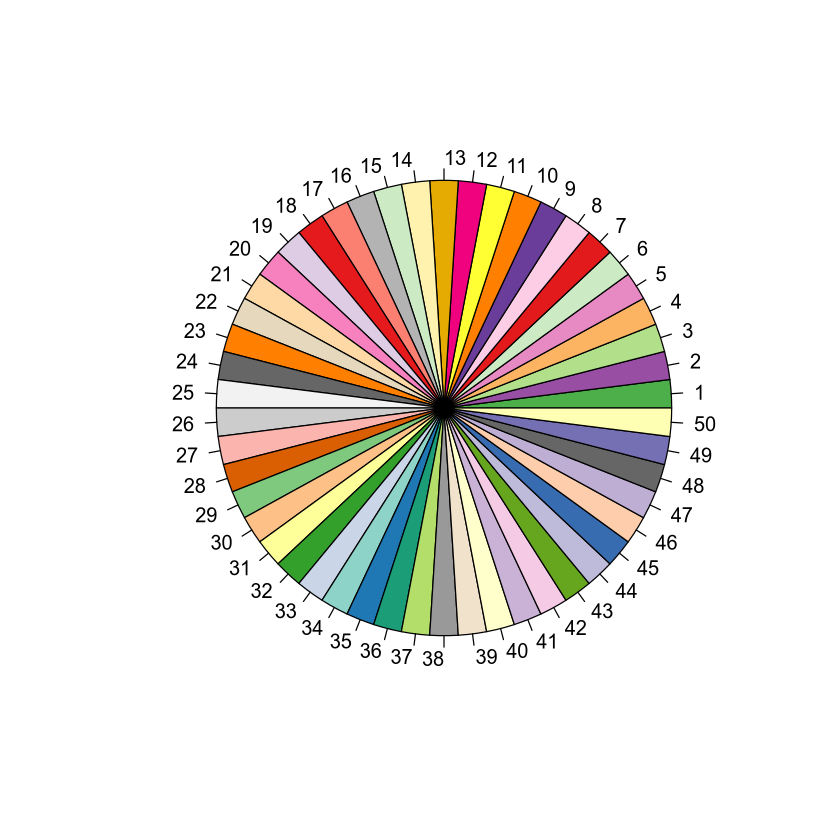

In [84]:
# Create a palett of distinctive colors
n <- 50
qual_col_pals = brewer.pal.info[brewer.pal.info$category == 'qual',]
col_vector = unlist(mapply(brewer.pal, qual_col_pals$maxcolors, rownames(qual_col_pals)))
pie(rep(1,n), col=sample(col_vector, n))

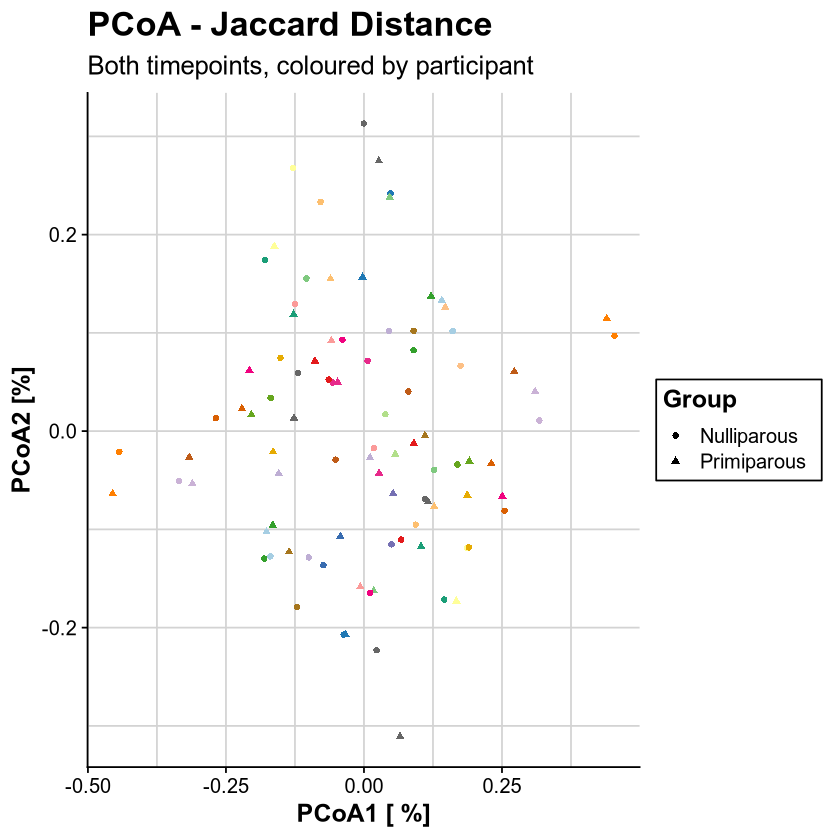

In [117]:
# Plot jaccard

jaccard_plot <- jaccard_merged |>
    ggplot(aes(x = Dim1, y = Dim2, col = Personalnumber, shape = Group)) +
    geom_point() +
    labs(
        x = paste("PCoA1 [", "%]"),
        y = paste0("PCoA2 [", "%]"),
        title = "PCoA - Jaccard Distance",
        subtitle = "Both timepoints, coloured by participant"
        #shape = "Timepoint"
    ) +
    scale_color_manual(values = col_vector) +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    ) +
        guides(col = "none")


jaccard_plot 
    

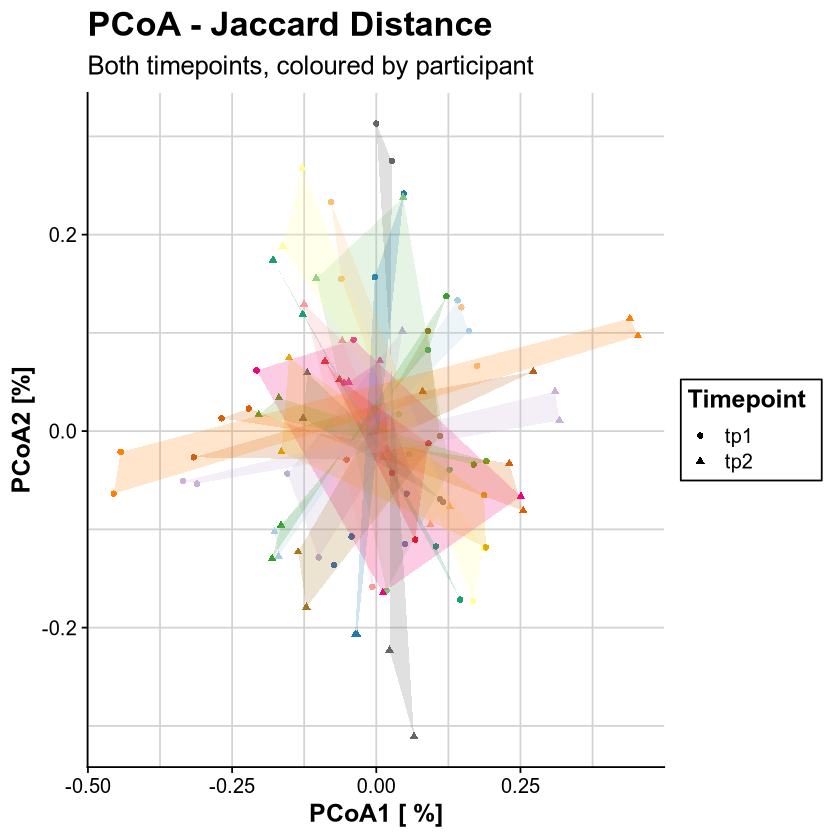

In [116]:
# Plot jaccard

jaccard_plot_guide <- jaccard_merged |>
    ggplot(aes(x = Dim1, y = Dim2, col = Personalnumber, shape = tp)) +
    geom_point() +
    #geom_line(aes(group = Personalnumber), linewidth = 1, alpha = 0.2) +
    geom_polygon(aes(group = Personalnumber, fill = Personalnumber), alpha = 0.2, color = NA ) +
    labs(
        x = paste("PCoA1 [", "%]"),
        y = paste0("PCoA2 [", "%]"),
        title = "PCoA - Jaccard Distance",
        subtitle = "Both timepoints, coloured by participant",
        shape = "Timepoint"
    ) +
    scale_color_manual(values = col_vector) +
    scale_fill_manual(values = col_vector) +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    ) +
# Remove Peronalnumber from legend so it isn't overcrowded
    guides(col = "none", fill = "none")


jaccard_plot_guide

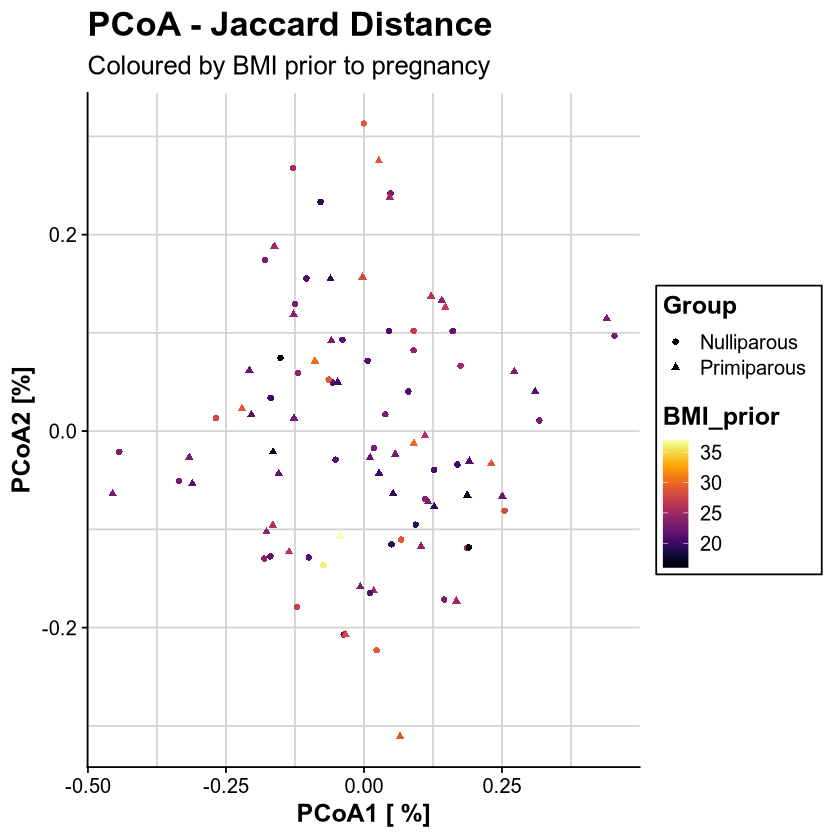

In [118]:
# Plot jaccard bmi groups

jaccard_plot <- jaccard_merged |>
    ggplot(aes(x = Dim1, y = Dim2, col = BMI_prior, shape = Group)) +
    geom_point() +
    labs(
        x = paste("PCoA1 [", "%]"),
        y = paste0("PCoA2 [", "%]"),
        title = "PCoA - Jaccard Distance",
        subtitle = "Coloured by BMI prior to pregnancy"
        #shape = "Timepoint"
    ) +
    #scale_color_manual(values = col_vector) +
    scale_color_viridis(option = "inferno") +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    ) 
        #guides(col = "none")


jaccard_plot 
    

# Aitchison=========================================================================================

# File ordering----------------------------------------------------------------------------------------------------------------------------------

In [88]:
aitchison_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/2025-09-24_aitchison_merged_tp1.csv" 
                          , header = TRUE, check.names = FALSE, quote='"') 
dim(aitchison_tp1)
head(aitchison_tp1)

[1] 50 18

,Sample_ID,Dim1,Dim2,Dim3,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,100000128343,-4.485908,-2.214533,3.7950250,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,1,0,0,0,0,NA
2,100000158999,-10.034065,-7.103666,-2.2201074,Nulliparous,S1a267fa,P1a267fa,32,3,No,55,21,1,0,0,0,0,18.5-25 Normal weight
3,100000101469,9.422225,-3.585906,-1.1919988,Nulliparous,Sa8397fa,P1ef420d,27,2,No,67,25,1,0,0,0,0,NA
4,100000103241,13.032350,-10.741796,1.5226435,Nulliparous,S1f862a6,P1f862a6,32,3,Yes,67,25,1,0,0,0,0,> 25 Overweight
5,100000141564,-21.318803,-3.179685,0.7491763,Nulliparous,S3c0f6ee,P3c0f6ee,31,3,No,97,36,1,0,0,1,1,> 25 Overweight
6,100000157404,3.569799,6.568899,-3.6252755,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,1,0,0,0,1,18.5-25 Normal weight


In [89]:
# Add column with timepoint 1
aitchison_tp1 <- aitchison_tp1 |> 
    mutate(tp = as.factor("tp1"))
head(aitchison_tp1)

,Sample_ID,Dim1,Dim2,Dim3,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<fct>
1,100000128343,-4.485908,-2.214533,3.7950250,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,1,0,0,0,0,NA,tp1
2,100000158999,-10.034065,-7.103666,-2.2201074,Nulliparous,S1a267fa,P1a267fa,32,3,No,55,21,1,0,0,0,0,18.5-25 Normal weight,tp1
3,100000101469,9.422225,-3.585906,-1.1919988,Nulliparous,Sa8397fa,P1ef420d,27,2,No,67,25,1,0,0,0,0,NA,tp1
4,100000103241,13.032350,-10.741796,1.5226435,Nulliparous,S1f862a6,P1f862a6,32,3,Yes,67,25,1,0,0,0,0,> 25 Overweight,tp1
5,100000141564,-21.318803,-3.179685,0.7491763,Nulliparous,S3c0f6ee,P3c0f6ee,31,3,No,97,36,1,0,0,1,1,> 25 Overweight,tp1
6,100000157404,3.569799,6.568899,-3.6252755,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,1,0,0,0,1,18.5-25 Normal weight,tp1


In [90]:
aitchison_tp2 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp2_nulliparous/tp2_alpha_beta_diversity/beta/2025-09-24_aitchison_merged_tp2.csv" , 
                          header = TRUE, check.names = FALSE, quote='"') 
dim(aitchison_tp2)
head(aitchison_tp2)

[1] 42 17

,Sample_ID,Dim1,Dim2,Dim3,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,100000144381,-12.121751,14.890513,1.337044,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,1,0,0,0,0
2,100000172865,-1.934724,-1.108059,-6.879284,Nulliparous,S1a267fa,P1a267fa,32,3,No,55,21,1,0,0,0,0
3,100000112243,-29.944408,8.464505,4.391256,Nulliparous,S1f862a6,P1f862a6,32,3,Yes,67,25,1,0,0,0,0
4,100000168325,9.987511,-11.235382,-4.285131,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,1,0,0,0,0
5,100000123362,-7.418159,-1.271044,3.049482,Nulliparous,S39fe1d7,P3db7da6,29,2,No,55,21,1,0,0,1,1
6,100000106341,10.962501,10.201270,3.009656,Nulliparous,S7e4a963,P424fd61,37,4,No,67,24,1,0,0,0,0


In [91]:
# Add column with timepoint 1
aitchison_tp2 <- aitchison_tp2 |> 
    mutate(tp = as.factor("tp2"))
head(aitchison_tp2)

,Sample_ID,Dim1,Dim2,Dim3,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
1,100000144381,-12.121751,14.890513,1.337044,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,1,0,0,0,0,tp2
2,100000172865,-1.934724,-1.108059,-6.879284,Nulliparous,S1a267fa,P1a267fa,32,3,No,55,21,1,0,0,0,0,tp2
3,100000112243,-29.944408,8.464505,4.391256,Nulliparous,S1f862a6,P1f862a6,32,3,Yes,67,25,1,0,0,0,0,tp2
4,100000168325,9.987511,-11.235382,-4.285131,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,1,0,0,0,0,tp2
5,100000123362,-7.418159,-1.271044,3.049482,Nulliparous,S39fe1d7,P3db7da6,29,2,No,55,21,1,0,0,1,1,tp2
6,100000106341,10.962501,10.201270,3.009656,Nulliparous,S7e4a963,P424fd61,37,4,No,67,24,1,0,0,0,0,tp2


In [93]:
# Tp1 has more Dim that are not needed so remove those that don't exist in tp2
# BMI groups are also not needed here since only exist for tp1
aitchison_tp1 <- aitchison_tp1[, names(aitchison_tp1) %in% names(aitchison_tp2)]
dim(aitchison_tp1)
head(aitchison_tp1)

[1] 50 18

,Sample_ID,Dim1,Dim2,Dim3,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
1,100000128343,-4.485908,-2.214533,3.7950250,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,1,0,0,0,0,tp1
2,100000158999,-10.034065,-7.103666,-2.2201074,Nulliparous,S1a267fa,P1a267fa,32,3,No,55,21,1,0,0,0,0,tp1
3,100000101469,9.422225,-3.585906,-1.1919988,Nulliparous,Sa8397fa,P1ef420d,27,2,No,67,25,1,0,0,0,0,tp1
4,100000103241,13.032350,-10.741796,1.5226435,Nulliparous,S1f862a6,P1f862a6,32,3,Yes,67,25,1,0,0,0,0,tp1
5,100000141564,-21.318803,-3.179685,0.7491763,Nulliparous,S3c0f6ee,P3c0f6ee,31,3,No,97,36,1,0,0,1,1,tp1
6,100000157404,3.569799,6.568899,-3.6252755,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,1,0,0,0,1,tp1


In [94]:
# Merge the tables verticaly so columns match

aitchison_merged <- rbind(aitchison_tp1, aitchison_tp2)
dim(aitchison_merged)
head(aitchison_merged)

[1] 92 18

,Sample_ID,Dim1,Dim2,Dim3,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
1,100000128343,-4.485908,-2.214533,3.7950250,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,1,0,0,0,0,tp1
2,100000158999,-10.034065,-7.103666,-2.2201074,Nulliparous,S1a267fa,P1a267fa,32,3,No,55,21,1,0,0,0,0,tp1
3,100000101469,9.422225,-3.585906,-1.1919988,Nulliparous,Sa8397fa,P1ef420d,27,2,No,67,25,1,0,0,0,0,tp1
4,100000103241,13.032350,-10.741796,1.5226435,Nulliparous,S1f862a6,P1f862a6,32,3,Yes,67,25,1,0,0,0,0,tp1
5,100000141564,-21.318803,-3.179685,0.7491763,Nulliparous,S3c0f6ee,P3c0f6ee,31,3,No,97,36,1,0,0,1,1,tp1
6,100000157404,3.569799,6.568899,-3.6252755,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,1,0,0,0,1,tp1


In [97]:
# Change variables to appropriate data type
aitchison_merged$Primipara <- as.factor(aitchison_merged$Primipara)
aitchison_merged$excess_weight <- as.factor(aitchison_merged$excess_weight)
aitchison_merged$Smoking <- as.factor(aitchison_merged$Smoking)
aitchison_merged$Alcohol <- as.factor(aitchison_merged$Alcohol)
aitchison_merged$High_stress <- as.factor(aitchison_merged$High_stress)
head(aitchison_merged)

,Sample_ID,Dim1,Dim2,Dim3,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>
1,100000128343,-4.485908,-2.214533,3.7950250,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,1,0,0,0,0,tp1
2,100000158999,-10.034065,-7.103666,-2.2201074,Nulliparous,S1a267fa,P1a267fa,32,3,No,55,21,1,0,0,0,0,tp1
3,100000101469,9.422225,-3.585906,-1.1919988,Nulliparous,Sa8397fa,P1ef420d,27,2,No,67,25,1,0,0,0,0,tp1
4,100000103241,13.032350,-10.741796,1.5226435,Nulliparous,S1f862a6,P1f862a6,32,3,Yes,67,25,1,0,0,0,0,tp1
5,100000141564,-21.318803,-3.179685,0.7491763,Nulliparous,S3c0f6ee,P3c0f6ee,31,3,No,97,36,1,0,0,1,1,tp1
6,100000157404,3.569799,6.568899,-3.6252755,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,1,0,0,0,1,tp1


## Plot----------------------------------------------------------------------------------------------------------------------------------------------------------

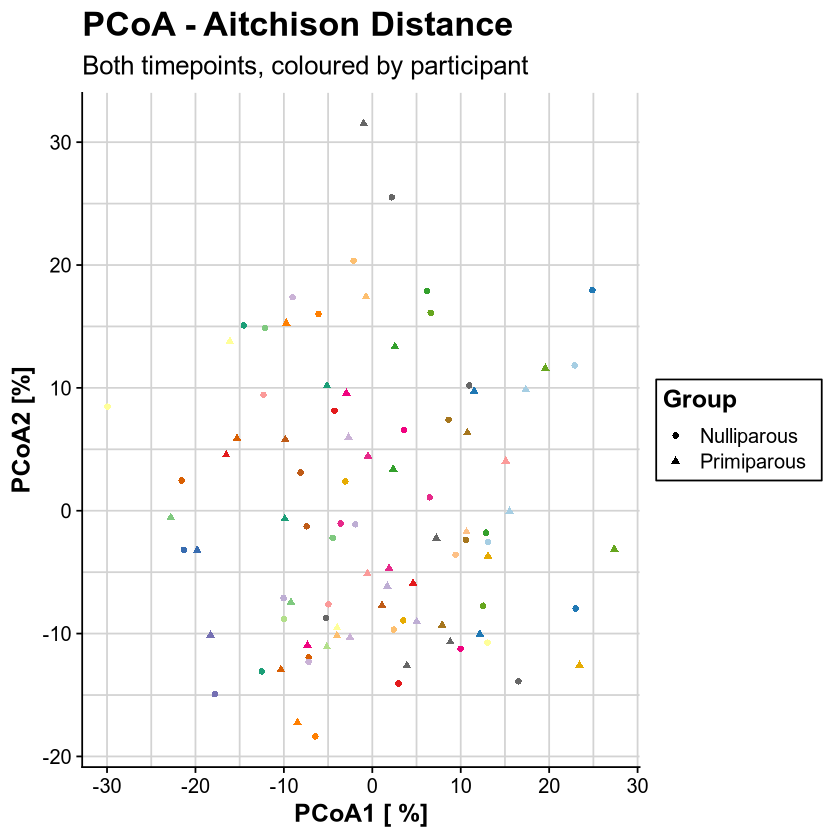

In [115]:
# Plot aitchison

aitchison_plot <- aitchison_merged |>
    ggplot(aes(x = Dim1, y = Dim2, col = Personalnumber, shape = Group)) +
    geom_point() +
    labs(
        x = paste("PCoA1 [", "%]"),
        y = paste0("PCoA2 [", "%]"),
        title = "PCoA - Aitchison Distance",
        subtitle = "Both timepoints, coloured by participant",
        shape = "Group"
    ) +
    scale_color_manual(values = col_vector) +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    ) +
    guides(col = "none")


aitchison_plot 
    

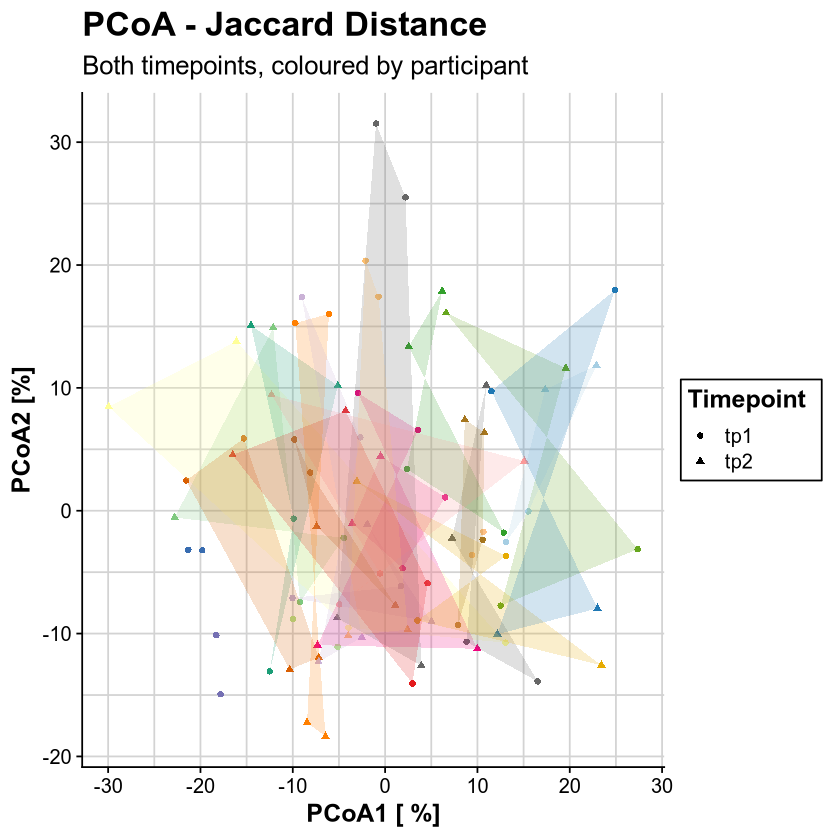

In [114]:
# Plot Aitchison joining personalnum

aitchison_plot_guide <- aitchison_merged |>
    ggplot(aes(x = Dim1, y = Dim2, col = Personalnumber, shape = tp)) +
    geom_point() +
    #geom_line(aes(group = Personalnumber), linewidth = 1, alpha = 0.2) +
    geom_polygon(aes(group = Personalnumber, fill = Personalnumber), alpha = 0.2, color = NA ) +
    labs(
        x = paste("PCoA1 [", "%]"),
        y = paste0("PCoA2 [", "%]"),
        title = "PCoA - Jaccard Distance",
        subtitle = "Both timepoints, coloured by participant",
        shape = "Timepoint"
    ) +
    scale_color_manual(values = col_vector) +
    scale_fill_manual(values = col_vector) +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    ) +
# Remove Peronalnumber from legend so it isn't overcrowded
    guides(col = "none", fill = "none")


aitchison_plot_guide

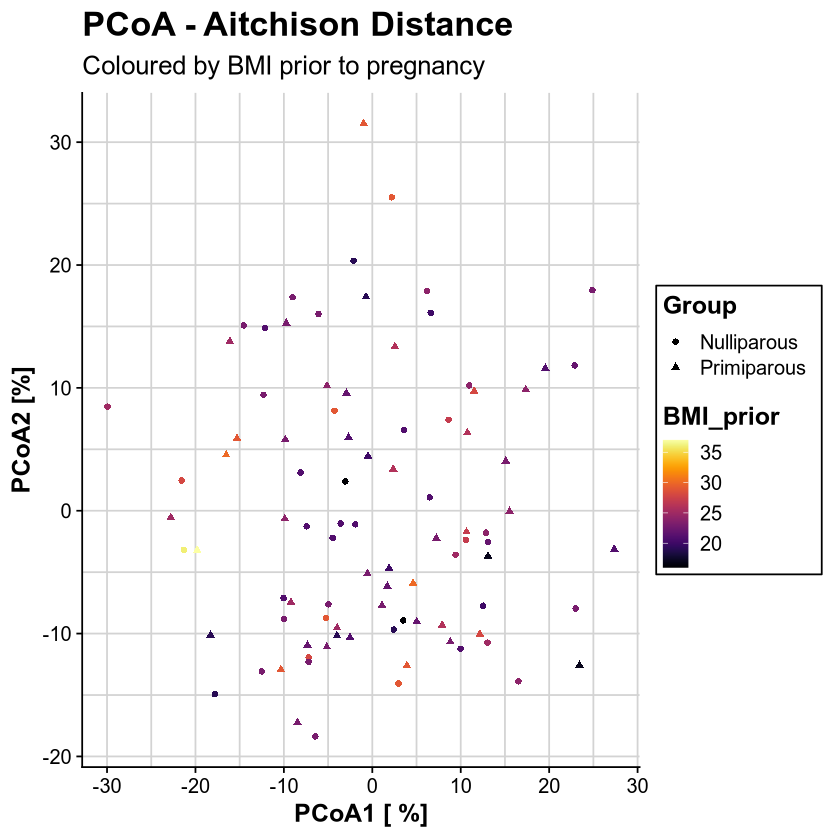

In [119]:
# Plot aitchison bmi groups

aitchison_plot_bmi <- aitchison_merged |>
    ggplot(aes(x = Dim1, y = Dim2, col = BMI_prior, shape = Group)) +
    geom_point() +
    labs(
        x = paste("PCoA1 [", "%]"),
        y = paste0("PCoA2 [", "%]"),
        title = "PCoA - Aitchison Distance",
        subtitle = "Coloured by BMI prior to pregnancy"
        #shape = "Timepoint"
    ) +
    #scale_color_manual(values = col_vector) +
    scale_color_viridis(option = "inferno") +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    ) 
        #guides(col = "none")

aitchison_plot_bmi 

# Bray Curtis========================================================================================

In [99]:
bray_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/2025-09-24_bray_curt_df_tp1.csv" , 
                     header = TRUE, check.names = FALSE, quote='"') 
dim(bray_tp1)
head(bray_tp1)

[1] 50 65

,Sample_ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,100000128343,0.11816263,0.23860921,-0.121801225,0.01822817,0.20343093,0.004276005,-0.02335950,-0.08150602,0.033102079,⋯,4,Yes,60,21,1,0,0,0,0,NA
2,100000158999,-0.15397106,0.09840774,0.099380914,-0.14336000,-0.18414812,-0.137528343,-0.05042553,0.01179888,-0.022823587,⋯,3,No,55,21,1,0,0,0,0,18.5-25 Normal weight
3,100000101469,0.16285717,0.09102754,-0.008449862,0.02784154,-0.01158490,-0.046943799,-0.22389111,-0.03327800,0.064510601,⋯,2,No,67,25,1,0,0,0,0,NA
4,100000103241,0.22032648,0.02743598,-0.132983146,0.01118636,0.06592769,0.071654899,-0.18568609,-0.02270179,0.011591352,⋯,3,Yes,67,25,1,0,0,0,0,> 25 Overweight
5,100000141564,-0.01169167,0.24725043,-0.110277883,0.09440979,-0.05937729,-0.050468605,0.12245766,0.08008029,0.041273995,⋯,3,No,97,36,1,0,0,1,1,> 25 Overweight
6,100000157404,-0.11516322,-0.02934096,-0.006853645,-0.16585210,-0.04146478,0.173594523,-0.01203156,-0.09846845,0.005093587,⋯,3,No,56,21,1,0,0,0,1,18.5-25 Normal weight


In [100]:
# Add column with timepoint 1
bray_tp1 <- bray_tp1 |> 
    mutate(tp = as.factor("tp1"))
head(bray_tp1)

,Sample_ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<fct>
1,100000128343,0.11816263,0.23860921,-0.121801225,0.01822817,0.20343093,0.004276005,-0.02335950,-0.08150602,0.033102079,⋯,Yes,60,21,1,0,0,0,0,NA,tp1
2,100000158999,-0.15397106,0.09840774,0.099380914,-0.14336000,-0.18414812,-0.137528343,-0.05042553,0.01179888,-0.022823587,⋯,No,55,21,1,0,0,0,0,18.5-25 Normal weight,tp1
3,100000101469,0.16285717,0.09102754,-0.008449862,0.02784154,-0.01158490,-0.046943799,-0.22389111,-0.03327800,0.064510601,⋯,No,67,25,1,0,0,0,0,NA,tp1
4,100000103241,0.22032648,0.02743598,-0.132983146,0.01118636,0.06592769,0.071654899,-0.18568609,-0.02270179,0.011591352,⋯,Yes,67,25,1,0,0,0,0,> 25 Overweight,tp1
5,100000141564,-0.01169167,0.24725043,-0.110277883,0.09440979,-0.05937729,-0.050468605,0.12245766,0.08008029,0.041273995,⋯,No,97,36,1,0,0,1,1,> 25 Overweight,tp1
6,100000157404,-0.11516322,-0.02934096,-0.006853645,-0.16585210,-0.04146478,0.173594523,-0.01203156,-0.09846845,0.005093587,⋯,No,56,21,1,0,0,0,1,18.5-25 Normal weight,tp1


In [101]:
bray_tp2 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp2_nulliparous/tp2_alpha_beta_diversity/beta/2025-09-24_bray_df_tp2.csv" ,
                     header = TRUE, check.names = FALSE, quote='"') 
dim(bray_tp2)
head(bray_tp2)

[1] 42 56

,Sample_ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,100000144381,-0.1681680499,0.14082310,-0.12020951,-0.04601324,-0.01220166,-0.011296720,-0.03704740,0.109900726,-0.02677928,⋯,36,4,Yes,60,21,1,0,0,0,0
2,100000172865,0.0416102679,0.06659320,0.03092386,0.03855434,-0.03713555,0.140022045,-0.14381769,-0.044333783,-0.09284274,⋯,32,3,No,55,21,1,0,0,0,0
3,100000112243,-0.1472481267,0.23896595,0.07547240,0.09542600,0.02693655,-0.002495859,0.02634059,0.004284817,0.01155811,⋯,32,3,Yes,67,25,1,0,0,0,0
4,100000168325,0.1376236697,-0.07421584,-0.09982778,0.18249476,-0.03573687,0.218488376,0.14811170,-0.068242834,0.05402089,⋯,31,3,No,56,21,1,0,0,0,0
5,100000123362,0.0002766147,0.12689441,0.11352676,-0.18362005,-0.09367156,0.044027433,0.03601597,0.117852539,-0.18793219,⋯,29,2,No,55,21,1,0,0,1,1
6,100000106341,-0.1322941749,-0.26078209,0.17797939,-0.06008052,0.17449688,0.057274931,0.12714519,0.180272065,-0.04441755,⋯,37,4,No,67,24,1,0,0,0,0


In [102]:
# Add column with timepoint 2
bray_tp2 <- bray_tp2 |> 
    mutate(tp = as.factor("tp2"))
head(bray_tp2)

,Sample_ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
1,100000144381,-0.1681680499,0.14082310,-0.12020951,-0.04601324,-0.01220166,-0.011296720,-0.03704740,0.109900726,-0.02677928,⋯,4,Yes,60,21,1,0,0,0,0,tp2
2,100000172865,0.0416102679,0.06659320,0.03092386,0.03855434,-0.03713555,0.140022045,-0.14381769,-0.044333783,-0.09284274,⋯,3,No,55,21,1,0,0,0,0,tp2
3,100000112243,-0.1472481267,0.23896595,0.07547240,0.09542600,0.02693655,-0.002495859,0.02634059,0.004284817,0.01155811,⋯,3,Yes,67,25,1,0,0,0,0,tp2
4,100000168325,0.1376236697,-0.07421584,-0.09982778,0.18249476,-0.03573687,0.218488376,0.14811170,-0.068242834,0.05402089,⋯,3,No,56,21,1,0,0,0,0,tp2
5,100000123362,0.0002766147,0.12689441,0.11352676,-0.18362005,-0.09367156,0.044027433,0.03601597,0.117852539,-0.18793219,⋯,2,No,55,21,1,0,0,1,1,tp2
6,100000106341,-0.1322941749,-0.26078209,0.17797939,-0.06008052,0.17449688,0.057274931,0.12714519,0.180272065,-0.04441755,⋯,4,No,67,24,1,0,0,0,0,tp2


In [103]:
# Tp1 has more X that are not needed so remove those that don't exist in tp2
# BMI groups are also not needed here since only exist for tp1
bray_tp1 <- bray_tp1[, names(bray_tp1) %in% names(bray_tp2)]
dim(bray_tp1)
head(bray_tp1)

[1] 50 57

,Sample_ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
1,100000128343,0.11816263,0.23860921,-0.121801225,0.01822817,0.20343093,0.004276005,-0.02335950,-0.08150602,0.033102079,⋯,4,Yes,60,21,1,0,0,0,0,tp1
2,100000158999,-0.15397106,0.09840774,0.099380914,-0.14336000,-0.18414812,-0.137528343,-0.05042553,0.01179888,-0.022823587,⋯,3,No,55,21,1,0,0,0,0,tp1
3,100000101469,0.16285717,0.09102754,-0.008449862,0.02784154,-0.01158490,-0.046943799,-0.22389111,-0.03327800,0.064510601,⋯,2,No,67,25,1,0,0,0,0,tp1
4,100000103241,0.22032648,0.02743598,-0.132983146,0.01118636,0.06592769,0.071654899,-0.18568609,-0.02270179,0.011591352,⋯,3,Yes,67,25,1,0,0,0,0,tp1
5,100000141564,-0.01169167,0.24725043,-0.110277883,0.09440979,-0.05937729,-0.050468605,0.12245766,0.08008029,0.041273995,⋯,3,No,97,36,1,0,0,1,1,tp1
6,100000157404,-0.11516322,-0.02934096,-0.006853645,-0.16585210,-0.04146478,0.173594523,-0.01203156,-0.09846845,0.005093587,⋯,3,No,56,21,1,0,0,0,1,tp1


In [104]:
# Merge the tables verticaly so columns match
bray_merged <- rbind(bray_tp1, bray_tp2)
dim(bray_merged)
head(bray_merged)

[1] 92 57

,Sample_ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
1,100000128343,0.11816263,0.23860921,-0.121801225,0.01822817,0.20343093,0.004276005,-0.02335950,-0.08150602,0.033102079,⋯,4,Yes,60,21,1,0,0,0,0,tp1
2,100000158999,-0.15397106,0.09840774,0.099380914,-0.14336000,-0.18414812,-0.137528343,-0.05042553,0.01179888,-0.022823587,⋯,3,No,55,21,1,0,0,0,0,tp1
3,100000101469,0.16285717,0.09102754,-0.008449862,0.02784154,-0.01158490,-0.046943799,-0.22389111,-0.03327800,0.064510601,⋯,2,No,67,25,1,0,0,0,0,tp1
4,100000103241,0.22032648,0.02743598,-0.132983146,0.01118636,0.06592769,0.071654899,-0.18568609,-0.02270179,0.011591352,⋯,3,Yes,67,25,1,0,0,0,0,tp1
5,100000141564,-0.01169167,0.24725043,-0.110277883,0.09440979,-0.05937729,-0.050468605,0.12245766,0.08008029,0.041273995,⋯,3,No,97,36,1,0,0,1,1,tp1
6,100000157404,-0.11516322,-0.02934096,-0.006853645,-0.16585210,-0.04146478,0.173594523,-0.01203156,-0.09846845,0.005093587,⋯,3,No,56,21,1,0,0,0,1,tp1


In [105]:
tail(bray_merged)

,Sample_ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
87,100000434772,-0.21614892,-0.03190498,0.02669224,0.018749840,-0.060301470,-0.16170351,0.12457292,-0.08046717,-0.101555988,⋯,3,No,73,26,0,0,0,0,1,tp2
88,100000433645,0.07878319,-0.17412632,-0.16495177,-0.119931377,-0.037233385,-0.25501604,0.08883997,-0.08694790,0.101525977,⋯,3,No,66,23,0,0,0,0,0,tp2
89,100000426050,-0.16465459,0.25336022,0.10325867,0.276684631,0.044102061,-0.09069604,0.02988705,0.02463363,0.041496201,⋯,3,Yes,88,30,0,0,0,0,0,tp2
90,100000185766,0.14745820,0.09146923,-0.23046102,0.054625473,0.007821833,0.01405874,-0.09687680,0.08114342,0.004700219,⋯,4,Yes,53,19,0,NA,NA,NA,0,tp2
91,100000418123,0.38214807,0.12204667,-0.05441571,-0.047355919,0.179534640,-0.13813895,0.09503141,0.01837418,-0.023020527,⋯,3,No,70,23,0,0,0,0,0,tp2
92,100000186718,0.24159309,0.01938427,0.13762183,0.003812373,-0.050785447,-0.06828986,-0.06237684,-0.07587469,-0.155074480,⋯,3,NA,54,21,0,0,0,0,0,tp2


In [107]:
bray_merged$Group <- as.factor(bray_merged$Group)
bray_merged$excess_weight <- as.factor(bray_merged$excess_weight)
bray_merged$Smoking <- as.factor(bray_merged$Smoking)
bray_merged$Alcohol <- as.factor(bray_merged$Alcohol)
bray_merged$High_stress <- as.factor(bray_merged$High_stress)
head(bray_merged)

,Sample_ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,tp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<fct>,<int>,<int>,<int>,<fct>,<fct>,<int>,<fct>,<fct>
1,100000128343,0.11816263,0.23860921,-0.121801225,0.01822817,0.20343093,0.004276005,-0.02335950,-0.08150602,0.033102079,⋯,4,Yes,60,21,1,0,0,0,0,tp1
2,100000158999,-0.15397106,0.09840774,0.099380914,-0.14336000,-0.18414812,-0.137528343,-0.05042553,0.01179888,-0.022823587,⋯,3,No,55,21,1,0,0,0,0,tp1
3,100000101469,0.16285717,0.09102754,-0.008449862,0.02784154,-0.01158490,-0.046943799,-0.22389111,-0.03327800,0.064510601,⋯,2,No,67,25,1,0,0,0,0,tp1
4,100000103241,0.22032648,0.02743598,-0.132983146,0.01118636,0.06592769,0.071654899,-0.18568609,-0.02270179,0.011591352,⋯,3,Yes,67,25,1,0,0,0,0,tp1
5,100000141564,-0.01169167,0.24725043,-0.110277883,0.09440979,-0.05937729,-0.050468605,0.12245766,0.08008029,0.041273995,⋯,3,No,97,36,1,0,0,1,1,tp1
6,100000157404,-0.11516322,-0.02934096,-0.006853645,-0.16585210,-0.04146478,0.173594523,-0.01203156,-0.09846845,0.005093587,⋯,3,No,56,21,1,0,0,0,1,tp1


## Plot-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

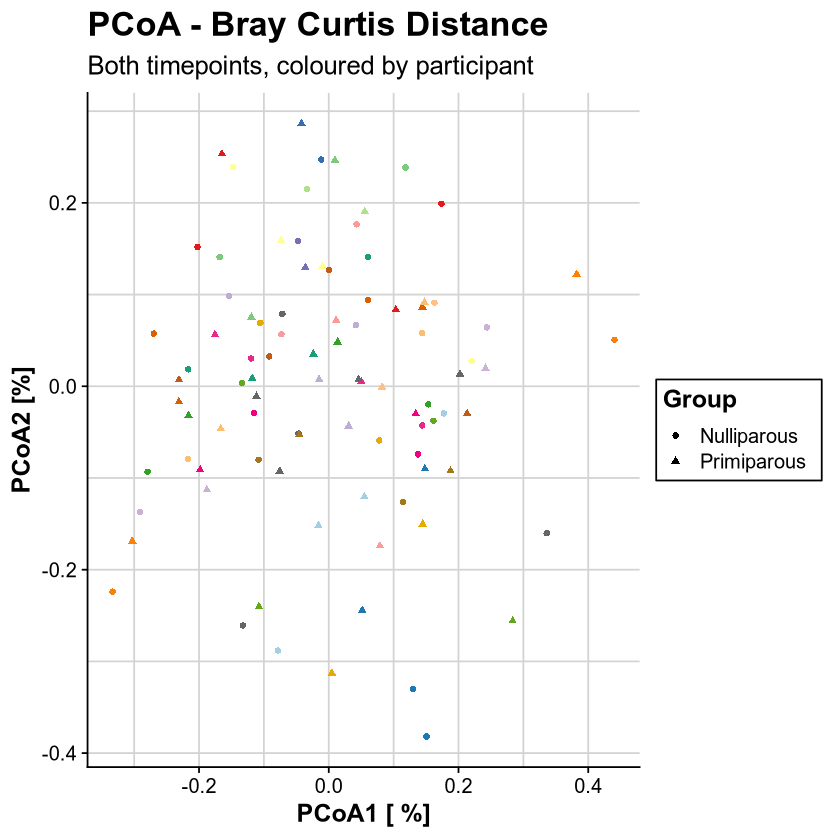

In [112]:
# Plot aitchison

bray_plot <- bray_merged |>
    ggplot(aes(x = X1, y = X2, col = Personalnumber, shape = Group)) +
    geom_point() +
    labs(
        x = paste("PCoA1 [", "%]"),
        y = paste0("PCoA2 [", "%]"),
        title = "PCoA - Bray Curtis Distance",
        subtitle = "Both timepoints, coloured by participant"
    ) +
    scale_color_manual(values = col_vector) +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    ) +
    guides(col = "none")


bray_plot 
    

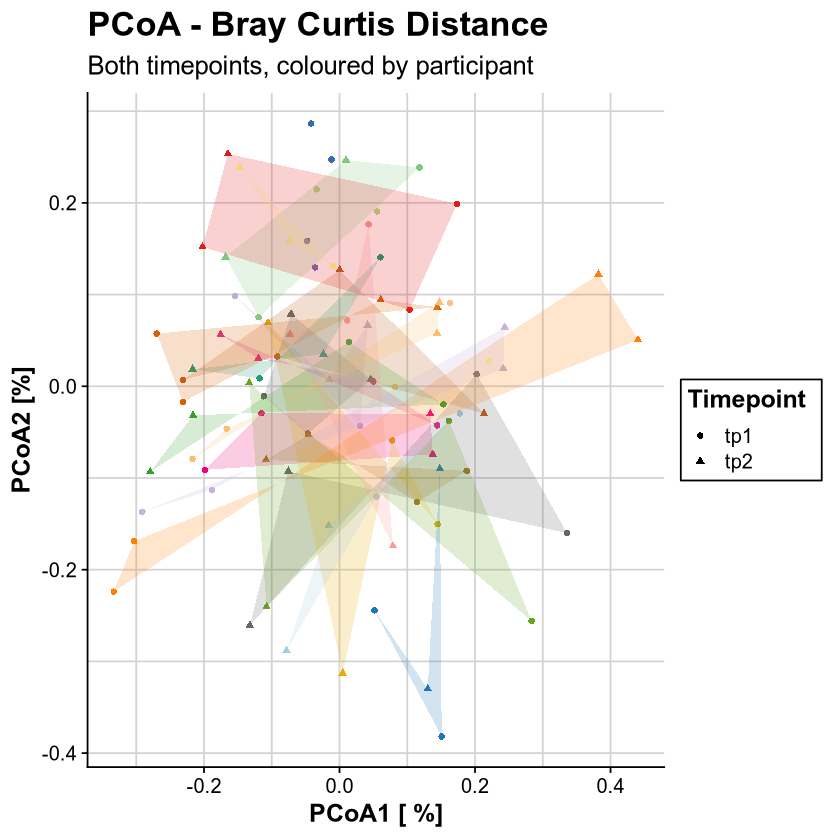

In [113]:
# Plot Bray

bray_plot_guide <- bray_merged |>
    ggplot(aes(x = X1, y = X2, col = Personalnumber, shape = tp)) +
    geom_point() +
    #geom_line(aes(group = Personalnumber), linewidth = 1, alpha = 0.2) +
    geom_polygon(aes(group = Personalnumber, fill = Personalnumber), alpha = 0.2, color = NA ) +
    labs(
        x = paste("PCoA1 [", "%]"),
        y = paste0("PCoA2 [", "%]"),
        title = "PCoA - Bray Curtis Distance",
        subtitle = "Both timepoints, coloured by participant",
        shape = "Timepoint"
    ) +
    scale_color_manual(values = col_vector) +
    scale_fill_manual(values = col_vector) +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    ) +
# Remove Peronalnumber from legend so it isn't overcrowded
    guides(col = "none", fill = "none")


bray_plot_guide

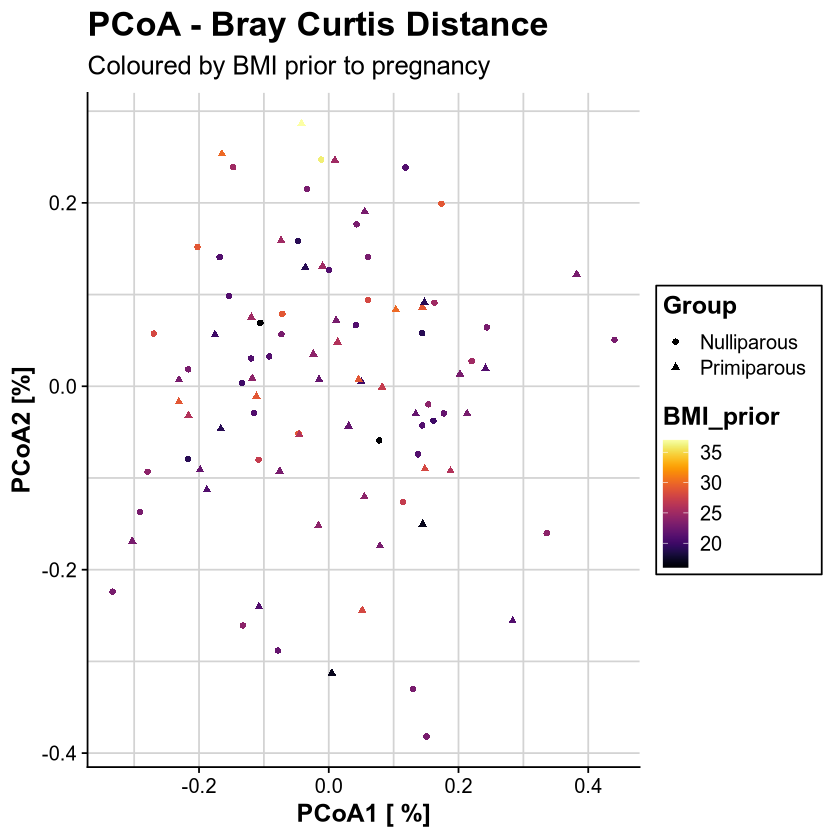

In [120]:
# Plot aitchison bmi groups

bray_plot_bmi <- bray_merged |>
    ggplot(aes(x = X1, y = X2, col = BMI_prior, shape = Group)) +
    geom_point() +
    labs(
        x = paste("PCoA1 [", "%]"),
        y = paste0("PCoA2 [", "%]"),
        title = "PCoA - Bray Curtis Distance",
        subtitle = "Coloured by BMI prior to pregnancy"
        #shape = "Timepoint"
    ) +
    #scale_color_manual(values = col_vector) +
    scale_color_viridis(option = "inferno") +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    ) 
        #guides(col = "none")

bray_plot_bmi 